In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

对比不同解码方式的rollout

In [ ]:
import re
import numpy as np
from pathlib import Path
from collections import Counter

def parse_diversity_line(line):
    """
    解析单行diversity数据，提取完整信息
    示例: diversity| distinct_answer_num: 6 | all_answer_num: 8 | distinct_answer_ratio: 0.75 | best_answer_ratio: 0.38 | correct_answer_number: 1 | best_is_correct: 0 | extracted_answers: ['0', '33.33', '22', '33.33', '33.33', '36.25', '24', '42'] | majority_answer: 33.33 | ground_truth_answer: 22
    """
    # 解析基础指标
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if not match:
        return None
    
    # 提取答案列表
    answers_pattern = r'extracted_answers:\s*\[(.*?)\]'
    answers_match = re.search(answers_pattern, line)
    extracted_answers = []
    if answers_match:
        # 解析答案列表字符串
        answers_str = answers_match.group(1)
        # 处理引号内的内容
        extracted_answers = re.findall(r"'([^']*)'", answers_str)
    
    # 提取多数投票答案
    majority_pattern = r'majority_answer:\s*([^\s|]+)'
    majority_match = re.search(majority_pattern, line)
    majority_answer = majority_match.group(1) if majority_match else None
    
    # 提取真实答案
    truth_pattern = r'ground_truth_answer:\s*([^\s|]+)'
    truth_match = re.search(truth_pattern, line)
    ground_truth = truth_match.group(1) if truth_match else None
    
    return {
        'distinct_answer_num': int(match.group(1)),
        'all_answer_num': int(match.group(2)),
        'best_answer_ratio': float(match.group(3)),
        'correct_answer_number': int(match.group(4)),
        'best_is_correct': int(match.group(5)),
        'extracted_answers': extracted_answers,
        'majority_answer': majority_answer,
        'ground_truth': ground_truth
    }

def calculate_reward_metrics(answers, majority_answer, ground_truth):
    """
    计算reward accuracy和相关指标
    
    Args:
        answers: 所有rollout的答案列表
        majority_answer: 多数投票答案
        ground_truth: 真实答案
    
    Returns:
        dict: 包含各项指标
    """
    n = len(answers)
    if n == 0 or majority_answer is None or ground_truth is None:
        return {
            'reward_accuracy': 0,
            'true_positive_ratio': 0,
            'true_negative_ratio': 0,
            'false_positive_ratio': 0,
            'false_negative_ratio': 0
        }
    
    # 为每个rollout计算估计奖励和真实奖励
    tp = fp = tn = fn = 0
    
    for ans in answers:
        est_reward = 1 if ans == majority_answer else 0  # 估计奖励：是否匹配多数投票
        true_reward = 1 if ans == ground_truth else 0     # 真实奖励：是否真实正确
        
        if est_reward == 1 and true_reward == 1:
            tp += 1  # True Positive: 估计正确且真实正确
        elif est_reward == 1 and true_reward == 0:
            fp += 1  # False Positive: 估计正确但真实错误
        elif est_reward == 0 and true_reward == 1:
            fn += 1  # False Negative: 估计错误但真实正确
        elif est_reward == 0 and true_reward == 0:
            tn += 1  # True Negative: 估计错误且真实错误
    
    # 计算各项指标
    total = tp + fp + tn + fn
    
    # Reward Accuracy: 估计奖励与真实奖励一致的比例
    reward_accuracy = (tp + tn) / total if total > 0 else 0
    
    # True Positive Ratio: TP / (TP + FN)
    true_positive_ratio = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # True Negative Ratio: TN / (TN + FP)
    true_negative_ratio = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Positive Ratio: FP / (FP + TN)
    false_positive_ratio = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # False Negative Ratio: FN / (FN + TP)
    false_negative_ratio = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    return {
        'reward_accuracy': reward_accuracy,
        'true_positive_ratio': true_positive_ratio,
        'true_negative_ratio': true_negative_ratio,
        'false_positive_ratio': false_positive_ratio,
        'false_negative_ratio': false_negative_ratio,
        # 也返回原始计数以便调试
        'tp_count': tp,
        'fp_count': fp,
        'tn_count': tn,
        'fn_count': fn
    }

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    过滤掉所有rollout相同的样本（无法产生梯度）
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0,
            'good_reward_ratio': 0,
            'zero_reward_ratio': 0,
            'bad_reward_ratio': 0,
            'effective_sample_ratio': 0,  # 有效样本比例（distinct_num > 1）
            'effective_reward_accuracy': 0,  # 有效样本中的reward accuracy
            'effective_tp_ratio': 0,
            'effective_fp_ratio': 0,
            'effective_tn_ratio': 0,
            'effective_fn_ratio': 0,
            'overall_reward_accuracy': 0,  # 所有样本（包括无效）的reward accuracy（供参考）
        }
    
    n_samples = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']
    
    # 原有的指标计算
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    avg_accuracy = avg_correct_num / all_answer_num
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    # 样本类型比例
    good_reward_count = zero_reward_count = bad_reward_count = 0
    for d in data_list:
        if d['distinct_answer_num'] == 1:
            zero_reward_count += 1
        elif d['best_is_correct'] == 1:
            good_reward_count += 1
        else:
            bad_reward_count += 1
    
    # ========== 有效样本过滤 ==========
    # 有效样本：distinct_answer_num > 1（有多样性，能产生梯度）
    effective_samples = [d for d in data_list if d['distinct_answer_num'] > 1]
    effective_sample_ratio = len(effective_samples) / n_samples if n_samples > 0 else 0
    
    # 在所有样本上计算overall reward accuracy（包括无效样本）
    total_tp_all = total_fp_all = total_tn_all = total_fn_all = 0
    
    # 在有效样本上计算effective reward metrics
    total_tp_eff = total_fp_eff = total_tn_eff = total_fn_eff = 0
    
    for d in data_list:
        if 'extracted_answers' not in d or not d['majority_answer'] or not d['ground_truth']:
            continue
            
        answers = d['extracted_answers']
        majority = d['majority_answer']
        truth = d['ground_truth']
        is_effective = d['distinct_answer_num'] > 1
        
        for ans in answers:
            est_reward = 1 if ans == majority else 0
            true_reward = 1 if ans == truth else 0
            
            # 统计所有样本
            if est_reward == 1 and true_reward == 1:
                total_tp_all += 1
            elif est_reward == 1 and true_reward == 0:
                total_fp_all += 1
            elif est_reward == 0 and true_reward == 0:
                total_tn_all += 1
            elif est_reward == 0 and true_reward == 1:
                total_fn_all += 1
            
            # 只统计有效样本
            if is_effective:
                if est_reward == 1 and true_reward == 1:
                    total_tp_eff += 1
                elif est_reward == 1 and true_reward == 0:
                    total_fp_eff += 1
                elif est_reward == 0 and true_reward == 0:
                    total_tn_eff += 1
                elif est_reward == 0 and true_reward == 1:
                    total_fn_eff += 1
    
    # 计算overall指标（所有样本）
    total_rollouts_all = total_tp_all + total_fp_all + total_tn_all + total_fn_all
    if total_rollouts_all > 0:
        overall_reward_accuracy = (total_tp_all + total_tn_all) / total_rollouts_all
        overall_tp_ratio = total_tp_all / total_rollouts_all
        overall_fp_ratio = total_fp_all / total_rollouts_all
        overall_tn_ratio = total_tn_all / total_rollouts_all
        overall_fn_ratio = total_fn_all / total_rollouts_all
    else:
        overall_reward_accuracy = overall_tp_ratio = overall_fp_ratio = overall_tn_ratio = overall_fn_ratio = 0
    
    # 计算effective指标（只有有效样本）
    total_rollouts_eff = total_tp_eff + total_fp_eff + total_tn_eff + total_fn_eff
    if total_rollouts_eff > 0:
        effective_reward_accuracy = (total_tp_eff + total_tn_eff) / total_rollouts_eff
        effective_tp_ratio = total_tp_eff / total_rollouts_eff
        effective_fp_ratio = total_fp_eff / total_rollouts_eff
        effective_tn_ratio = total_tn_eff / total_rollouts_eff
        effective_fn_ratio = total_fn_eff / total_rollouts_eff
    else:
        effective_reward_accuracy = effective_tp_ratio = effective_fp_ratio = effective_tn_ratio = effective_fn_ratio = 0
    
    # 验证有效样本的比例之和为1
    if total_rollouts_eff > 0:
        assert abs(effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio - 1.0) < 1e-10, \
               f"有效样本比例之和应为1，实际为{effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio}"
    
    return {
        # 原有指标
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,
        'num_samples': n_samples,
        'good_reward_ratio': good_reward_count / n_samples,
        'zero_reward_ratio': zero_reward_count / n_samples,
        'bad_reward_ratio': bad_reward_count / n_samples,
        
        # 新增：有效样本比例
        'effective_sample_ratio': effective_sample_ratio,
        
        # 有效样本上的reward metrics
        'effective_reward_accuracy': effective_reward_accuracy,
        'effective_tp_ratio': effective_tp_ratio,
        'effective_fp_ratio': effective_fp_ratio,
        'effective_tn_ratio': effective_tn_ratio,
        'effective_fn_ratio': effective_fn_ratio,
        
        # 整体指标（供参考）
        'overall_reward_accuracy': overall_reward_accuracy,
    }

def print_metrics_table(metrics_list):
    """
    打印指标表格（包含有效样本指标）
    """
    print("\n" + "="*200)
    header = f"{'File':<60} {'Samples':<6} {'Eff%':<6} {'Distinct':<8} {'Consist':<7} {'RollAcc':<7} {'VoteAcc':<7} "
    header += f"{'GoodR':<6} {'ZeroR':<6} {'BadR':<6} "
    header += f"{'EffTP':<6} {'EffFP':<6} {'EffTN':<6} {'EffFN':<6} {'EffRewAcc':<8} {'AllRewAcc':<8}"
    print(header)
    print("="*200)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:60] + ".." if len(metrics['filename']) > 40 else metrics['filename']
            print(f"{filename:<60} {metrics['num_samples']:<6} "
                  f"{metrics['effective_sample_ratio']:<6.2f} "
                  f"{metrics['avg_distinct_num']:<8.2f} "
                  f"{metrics['consistency']:<7.3f} "
                  f"{metrics['avg_accuracy']:<7.3f} "
                  f"{metrics['voting_accuracy']:<7.3f} "
                  f"{metrics['good_reward_ratio']:<6.3f} "
                  f"{metrics['zero_reward_ratio']:<6.3f} "
                  f"{metrics['bad_reward_ratio']:<6.3f} "
                  f"{metrics['effective_tp_ratio']:<6.3f} "
                  f"{metrics['effective_fp_ratio']:<6.3f} "
                  f"{metrics['effective_tn_ratio']:<6.3f} "
                  f"{metrics['effective_fn_ratio']:<6.3f} "
                  f"{metrics['effective_reward_accuracy']:<8.3f} "
                  f"{metrics['overall_reward_accuracy']:<8.3f}")
    
    print("="*200)
    print("\n指标说明:")
    print("  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)")
    print("  Distinct: 平均不同答案数量")
    print("  Consist:  一致性 (最常见答案比例)")
    print("  RollAcc:  rollout平均准确率")
    print("  VoteAcc:  投票准确率")
    print("  GoodR:    好样本比例 (投票正确且多样)")
    print("  ZeroR:    零奖励比例 (无多样性)")
    print("  BadR:     坏样本比例 (投票错误)")
    print("  EffTP:    有效样本中估计正确且真实正确比例")
    print("  EffFP:    有效样本中估计正确但真实错误比例") 
    print("  EffTN:    有效样本中估计错误且真实错误比例")
    print("  EffFN:    有效样本中估计错误但真实正确比例")
    print("  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)")
    print("  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)")
    print(f"\n  验证: EffTP+EffFP+EffTN+EffFN = {metrics['effective_tp_ratio']+metrics['effective_fp_ratio']+metrics['effective_tn_ratio']+metrics['effective_fn_ratio']:.3f} (应为1)")

def process_file(filename, max_line=0):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    if max_line > 0:
        data_list = data_list[:max_line]
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics


In [ ]:
# 画表格
log_files = [
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32.log',
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32_weighted_confidence.log',
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file, max_line=80)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

训练过程中的metric曲线

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import ast
import math
from collections import Counter
import matplotlib
import pandas as pd

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
matplotlib.rcParams["axes.unicode_minus"] = False


# ============================================================
# Basic utilities
# ============================================================

def moving_average(data, window=10, stride=1):
    """
    NaN-aware sliding-window moving average.
    Keeps original x-axis index.

    window=60, stride=10:
        average [0:60], [10:70], [20:80], ...
    x coordinate uses the right endpoint of each window.
    """
    data = np.asarray(data, dtype=float)

    if len(data) == 0:
        return np.asarray([]), np.asarray([])

    if len(data) < window:
        return data, np.arange(1, len(data) + 1)

    y = []
    x = []

    for start in range(0, len(data) - window + 1, stride):
        end = start + window
        window_values = data[start:end]

        if np.all(np.isnan(window_values)):
            y.append(np.nan)
        else:
            y.append(np.nanmean(window_values))

        x.append(end)

    return np.asarray(y, dtype=float), np.asarray(x, dtype=int)


def safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def safe_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default


def parse_list_field(s):
    """
    Parse list-like fields from logs:
        ['2', '2', '3']
    """
    if s is None:
        return []

    try:
        value = ast.literal_eval(s)
        if isinstance(value, list):
            return [str(v).strip() for v in value]
        return []
    except Exception:
        return [
            a.strip().strip("'\"")
            for a in str(s).strip("[]").split(",")
            if a.strip()
        ]


def normalized_entropy(answers):
    """
    Normalized answer entropy in [0, 1].
    Higher means more answer diversity.
    """
    if not answers:
        return 0.0

    counter = Counter(answers)
    total = sum(counter.values())

    if len(counter) <= 1 or total <= 0:
        return 0.0

    probs = [c / total for c in counter.values()]
    entropy = -sum(p * math.log(p + 1e-12) for p in probs)
    return entropy / math.log(len(counter))


def normalize_adv(rewards):
    rewards = np.asarray(rewards, dtype=float)
    std = rewards.std()

    if std < 1e-8:
        return np.zeros_like(rewards)

    return (rewards - rewards.mean()) / (std + 1e-8)


def reward_accuracy_from_answers(answers, pseudo_label, truth):
    """
    pseudo reward:
        1 if answer == pseudo_label else 0

    oracle reward:
        1 if answer == truth else 0

    reward accuracy:
        mean(pseudo_reward == oracle_reward)
    """
    if not answers or pseudo_label == "" or truth == "":
        return np.nan

    pseudo_rewards = np.asarray(
        [1.0 if ans == pseudo_label else 0.0 for ans in answers],
        dtype=float,
    )
    oracle_rewards = np.asarray(
        [1.0 if ans == truth else 0.0 for ans in answers],
        dtype=float,
    )

    return float(np.mean(pseudo_rewards == oracle_rewards))


def advantage_metrics_from_answers(answers, pseudo_label, truth):
    """
    Returns:
        adv_sign_agreement, adv_corr, adv_mse

    Only meaningful when both pseudo rewards and oracle rewards have non-zero variance.
    Otherwise returns NaN.
    """
    if not answers or pseudo_label == "" or truth == "":
        return np.nan, np.nan, np.nan

    pseudo_rewards = np.asarray(
        [1.0 if ans == pseudo_label else 0.0 for ans in answers],
        dtype=float,
    )
    oracle_rewards = np.asarray(
        [1.0 if ans == truth else 0.0 for ans in answers],
        dtype=float,
    )

    pseudo_adv = normalize_adv(pseudo_rewards)
    oracle_adv = normalize_adv(oracle_rewards)

    if pseudo_adv.std() < 1e-8 or oracle_adv.std() < 1e-8:
        return np.nan, np.nan, np.nan

    sign_agreement = float(np.mean(np.sign(pseudo_adv) == np.sign(oracle_adv)))
    corr = float(np.corrcoef(pseudo_adv, oracle_adv)[0, 1])
    mse = float(np.mean((pseudo_adv - oracle_adv) ** 2))

    return sign_agreement, corr, mse


def auto_ylim_from_series(series_list, margin_ratio=0.12, min_span=0.03):
    values = []

    for series in series_list:
        arr = np.asarray(series, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) > 0:
            values.extend(arr.tolist())

    if len(values) == 0:
        return None

    lo, hi = min(values), max(values)
    span = hi - lo

    if span < min_span:
        mid = (lo + hi) / 2
        lo = mid - min_span / 2
        hi = mid + min_span / 2
        span = hi - lo

    lo = lo - span * margin_ratio
    hi = hi + span * margin_ratio

    if min(values) >= 0 and max(values) <= 1:
        lo = max(0.0, lo)
        hi = min(1.0, hi)

        if hi - lo < min_span:
            if hi >= 0.98:
                lo = max(0.0, hi - min_span)
            elif lo <= 0.02:
                hi = min(1.0, lo + min_span)

    return lo, hi


def truncate_values(values, max_len=None):
    values = np.asarray(values, dtype=float)

    if max_len is None:
        return values

    return values[:max_len]


# ============================================================
# Log parsing
# ============================================================

def parse_diversity_line(line):
    """
    Expected example:
    diversity| distinct_answer_num: 1 | all_answer_num: 8 |
    distinct_answer_ratio: 0.12 | best_answer_ratio: 1.00 |
    correct_answer_number: 8 | best_is_correct: 1 |
    extracted_answers: ['2', ...] | normalized_answers: ['2', ...] |
    majority_answer: 2 | ground_truth_answer: 2
    """
    try:
        parts = line.strip().split("diversity|", 1)[1].split("|")
        data = {}

        for part in parts:
            part = part.strip()
            if ": " in part:
                k, v = part.split(": ", 1)
                data[k.strip()] = v.strip()

        extracted_answers = parse_list_field(data.get("extracted_answers", "[]"))
        normalized_answers = parse_list_field(data.get("normalized_answers", "[]"))

        return {
            "distinct_answer_num": safe_int(data.get("distinct_answer_num", 0)),
            "all_answer_num": safe_int(
                data.get("all_answer_num", len(normalized_answers) or len(extracted_answers))
            ),
            "distinct_answer_ratio": safe_float(data.get("distinct_answer_ratio", 0)),
            "best_answer_ratio": safe_float(data.get("best_answer_ratio", 0)),
            "correct_answer_number": safe_int(data.get("correct_answer_number", 0)),
            "best_is_correct": safe_float(data.get("best_is_correct", np.nan)),
            "majority_answer": data.get("majority_answer", "").strip(),
            "ground_truth": data.get("ground_truth_answer", "").strip(),
            "extracted_answers": extracted_answers,
            "normalized_answers": normalized_answers,
        }

    except Exception:
        return None


def parse_step_rewards(log_file):
    rewards = []
    grads = []

    num = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?"
    pattern = re.compile(
        rf"\[Step\s+\d+/\d+\]\s+reward=({num}),\s+grad=({num})"
    )

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards.append(float(m.group(1)))
                grads.append(float(m.group(2)))

    return rewards, grads


def extract_metrics_from_log(log_file, use_best_is_correct=True):
    """
    Extract dynamic metrics from one log file.

    use_best_is_correct:
        True: pseudo_label_acc uses log field best_is_correct.
        False: pseudo_label_acc uses majority_answer == ground_truth.
    """
    metrics = {
        # Pseudo-label / reward diagnostics
        "pseudo_label_acc": [],
        "reward_acc": [],
        "valid_reward_acc": [],
        "effective_ratio": [],

        # Advantage diagnostics
        "adv_sign_eff": [],
        "adv_corr_eff": [],
        "adv_mse_eff": [],

        # Rollout quality / diversity
        "pass_at_8": [],
        "correct_answer_ratio": [],
        "rollout_diversity": [],
        "answer_entropy": [],
        "majority_ratio": [],
        "unique_answer_num": [],
        "no_diversity_ratio": [],

        # Step-level training logs
        "step_reward": [],
        "grad_norm": [],
    }

    step_rewards, step_grads = parse_step_rewards(log_file)
    metrics["step_reward"] = step_rewards
    metrics["grad_norm"] = step_grads

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            if "diversity|" not in line:
                continue

            data = parse_diversity_line(line)
            if data is None:
                continue

            answers = (
                data["normalized_answers"]
                if len(data["normalized_answers"]) > 0
                else data["extracted_answers"]
            )

            pseudo_label = data["majority_answer"]
            truth = data["ground_truth"]

            all_answer_num = data["all_answer_num"]
            if all_answer_num <= 0:
                all_answer_num = len(answers)

            distinct_answer_num = data["distinct_answer_num"]
            if distinct_answer_num <= 0 and answers:
                distinct_answer_num = len(set(answers))

            effective_group = distinct_answer_num > 1

            # 1. Pseudo-label accuracy
            if use_best_is_correct and not np.isnan(data["best_is_correct"]):
                pseudo_label_acc = data["best_is_correct"]
            else:
                pseudo_label_acc = (
                    1.0
                    if pseudo_label != "" and truth != "" and pseudo_label == truth
                    else 0.0
                )

            # 2. Reward accuracy over all groups
            reward_acc = reward_accuracy_from_answers(answers, pseudo_label, truth)

            # 3. Reward accuracy over effective groups only
            # Keep NaN for no-diversity groups to preserve original x-axis
            valid_reward_acc = reward_acc if effective_group else np.nan

            # 4. Effective group flag
            effective_ratio = 1.0 if effective_group else 0.0

            # 5. Advantage-level diagnostics
            adv_sign, adv_corr, adv_mse = advantage_metrics_from_answers(
                answers, pseudo_label, truth
            )

            # 6. pass@8 and single-rollout accuracy
            correct_answer_number = data["correct_answer_number"]
            if correct_answer_number <= 0 and truth != "" and answers:
                correct_answer_number = sum(ans == truth for ans in answers)

            pass_at_8 = 1.0 if correct_answer_number > 0 else 0.0
            correct_answer_ratio = (
                correct_answer_number / all_answer_num
                if all_answer_num > 0
                else np.nan
            )

            # 7. Diversity metrics
            rollout_diversity = (
                distinct_answer_num / all_answer_num
                if all_answer_num > 0
                else data["distinct_answer_ratio"]
            )

            answer_entropy = normalized_entropy(answers)

            if answers and pseudo_label != "":
                majority_count = sum(ans == pseudo_label for ans in answers)
                majority_ratio = majority_count / len(answers)
            else:
                majority_ratio = data["best_answer_ratio"]

            no_diversity_ratio = 1.0 if not effective_group else 0.0

            metrics["pseudo_label_acc"].append(pseudo_label_acc)
            metrics["reward_acc"].append(reward_acc)
            metrics["valid_reward_acc"].append(valid_reward_acc)
            metrics["effective_ratio"].append(effective_ratio)

            metrics["adv_sign_eff"].append(adv_sign)
            metrics["adv_corr_eff"].append(adv_corr)
            metrics["adv_mse_eff"].append(adv_mse)

            metrics["pass_at_8"].append(pass_at_8)
            metrics["correct_answer_ratio"].append(correct_answer_ratio)
            metrics["rollout_diversity"].append(rollout_diversity)
            metrics["answer_entropy"].append(answer_entropy)
            metrics["majority_ratio"].append(majority_ratio)
            metrics["unique_answer_num"].append(distinct_answer_num)
            metrics["no_diversity_ratio"].append(no_diversity_ratio)

    return metrics


# ============================================================
# Label helpers
# ============================================================

def pretty_label(log_file):
    name = Path(log_file).stem
    name = name.replace("checkpoints_", "")
    name = name.replace("gsm8k_num_generation8_test_", "")
    name = name.replace("_temperature1.0", "")
    name = name.replace("_temperature0.6", "_temp0.6")
    name = name.replace("_temperature0.8", "_temp0.8")
    name = name.replace("_temperature1.2", "_temp1.2")
    name = name.replace("_lr5e-6", "")
    return name


def get_shortest_lengths_by_metric(log_files, use_best_is_correct=True):
    """
    Compute shortest raw length for each metric across log files.
    Raw length preserves NaNs and original timeline.
    """
    all_metrics = {
        log_file: extract_metrics_from_log(
            log_file,
            use_best_is_correct=use_best_is_correct,
        )
        for log_file in log_files
    }

    metric_names = set()
    for metrics in all_metrics.values():
        metric_names.update(metrics.keys())

    shortest = {}

    for metric_name in metric_names:
        lengths = []
        for log_file in log_files:
            values = all_metrics[log_file].get(metric_name, [])
            if len(values) > 0:
                lengths.append(len(values))

        shortest[metric_name] = min(lengths) if lengths else None

    return shortest, all_metrics


# ============================================================
# Plotting
# ============================================================

def plot_metric_across_files(
    log_files,
    metric_name,
    metric_label,
    save_dir=None,
    smooth_window=20,
    smooth_stride=1,
    xlim=None,
    ylim=None,
    min_valid_points=1,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=False,
    cached_metrics=None,
    shortest_lengths=None,
):
    plt.figure(figsize=(7, 5))

    plotted = False
    plotted_series = []
    max_x = 0

    markers = ["s", "^", "o", "D", "v", "P", "X", "<", ">"]

    shortest_len = None
    if truncate_to_shortest and shortest_lengths is not None:
        shortest_len = shortest_lengths.get(metric_name)
        print(f"[truncate] {metric_name}: shortest raw length = {shortest_len}")

    for file_idx, log_file in enumerate(log_files):
        if cached_metrics is not None and log_file in cached_metrics:
            metrics = cached_metrics[log_file]
        else:
            metrics = extract_metrics_from_log(
                log_file,
                use_best_is_correct=use_best_is_correct,
            )

        values = truncate_values(
            metrics.get(metric_name, []),
            max_len=shortest_len,
        )

        print(
            f"{metric_name}: {len(values)} raw points, "
            f"{np.sum(~np.isnan(values))} valid points in {log_file}"
        )

        if len(values) == 0:
            print(f"No {metric_name} data in {log_file}")
            continue

        if np.sum(~np.isnan(values)) < min_valid_points:
            print(f"Too few valid {metric_name} points in {log_file}")
            continue

        if len(values) >= smooth_window:
            y_plot, x_plot = moving_average(
                values,
                window=smooth_window,
                stride=smooth_stride,
            )
        else:
            y_plot = values
            x_plot = np.arange(1, len(values) + 1)

        # Remove windows that are entirely NaN
        valid_windows = ~np.isnan(y_plot)
        y_plot = y_plot[valid_windows]
        x_plot = x_plot[valid_windows]

        if len(y_plot) == 0:
            print(f"All smoothed windows are NaN for {metric_name} in {log_file}")
            continue

        marker = markers[file_idx % len(markers)]

        plt.plot(
            x_plot,
            y_plot,
            linewidth=2,
            label=pretty_label(log_file),
            marker=marker,
            markersize=6,
            markerfacecolor="none",
            markeredgewidth=1.4,
            markevery=markevery,
        )

        plotted_series.append(y_plot)
        max_x = max(max_x, int(x_plot[-1]))
        plotted = True

    if not plotted:
        print(f"No plottable data for {metric_name}")
        plt.close()
        return

    if metric_name in ["step_reward", "grad_norm"]:
        plt.xlabel("Training Step")
    else:
        plt.xlabel("Rollout Group Index")

    plt.ylabel(metric_label)
    plt.title(metric_label)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")

    if xlim is not None:
        plt.xlim(*xlim)
    else:
        plt.xlim(1, max_x)

    if ylim is not None:
        plt.ylim(*ylim)
    else:
        auto_ylim = auto_ylim_from_series(plotted_series)
        if auto_ylim is not None:
            plt.ylim(*auto_ylim)

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        suffix = "_truncated" if truncate_to_shortest else ""
        save_path = save_dir / f"{metric_name}{suffix}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    plt.close()


def plot_all_metrics_across_files(
    log_files,
    save_dir=None,
    smooth_window=60,
    smooth_stride=10,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=False,
):
    metric_specs = [
        # Core pseudo-label / reward diagnostics
        ("pseudo_label_acc", "Pseudo-label Accuracy"),
        ("reward_acc", "Reward Accuracy"),
        # ("valid_reward_acc", "Reward Accuracy on Effective Groups"),
        # ("effective_ratio", "Effective Group Ratio"),

        # # Advantage diagnostics
        # ("adv_sign_eff", "Advantage Sign Agreement on Effective Groups"),
        # ("adv_corr_eff", "Advantage Correlation on Effective Groups"),
        # ("adv_mse_eff", "Advantage MSE on Effective Groups"),

        # Rollout quality
        ("pass_at_8", "Pass@8"),
        ("correct_answer_ratio", "Single-rollout Accuracy"),

        # Diversity / stability
        # ("rollout_diversity", "Rollout Diversity"),
        # ("answer_entropy", "Answer Entropy"),
        # ("majority_ratio", "Majority Ratio"),
        # ("no_diversity_ratio", "No-diversity Ratio"),

        # # Trainer logs
        # ("step_reward", "Step Reward"),
        # ("grad_norm", "Gradient Norm"),
    ]

    shortest_lengths = None
    cached_metrics = None

    if truncate_to_shortest:
        shortest_lengths, cached_metrics = get_shortest_lengths_by_metric(
            log_files,
            use_best_is_correct=use_best_is_correct,
        )

    for metric_name, metric_label in metric_specs:
        plot_metric_across_files(
            log_files=log_files,
            metric_name=metric_name,
            metric_label=metric_label,
            save_dir=save_dir,
            smooth_window=smooth_window,
            smooth_stride=smooth_stride,
            markevery=markevery,
            use_best_is_correct=use_best_is_correct,
            truncate_to_shortest=truncate_to_shortest,
            cached_metrics=cached_metrics,
            shortest_lengths=shortest_lengths,
        )


# ============================================================
# Summary to dict / DataFrame
# ============================================================

def summarize_log_metrics(
    log_files,
    use_best_is_correct=True,
    save_dir=None,
    save_csv=True,
    truncate_to_shortest=False,
    human_max_length=None
):
    """
    Return:
        summary_dict: nested dict
        summary_df: pandas DataFrame

    If truncate_to_shortest=True:
        each metric is truncated to the shortest raw length across log files
        before summary statistics are computed.
    """
    summary_dict = {}
    rows = []

    shortest_lengths = None
    cached_metrics = None

    if truncate_to_shortest:
        shortest_lengths, cached_metrics = get_shortest_lengths_by_metric(
            log_files,
            use_best_is_correct=use_best_is_correct,
        )

        print("\n[truncate_to_shortest=True]")
        for metric_name in sorted(shortest_lengths):
            print(f"  {metric_name:<24}: {shortest_lengths[metric_name]}")

    for log_file in log_files:
        label = pretty_label(log_file)

        if cached_metrics is not None and log_file in cached_metrics:
            metrics = cached_metrics[log_file]
        else:
            metrics = extract_metrics_from_log(
                log_file,
                use_best_is_correct=use_best_is_correct,
            )

        summary_dict[label] = {}

        print("\n" + "=" * 80)
        print(label)
        print("=" * 80)

        for metric_name, values in metrics.items():
            max_len = (
                shortest_lengths.get(metric_name)
                if truncate_to_shortest and shortest_lengths is not None
                else None
            )

            if human_max_length is not None:
                arr = truncate_values(values, max_len=human_max_length)
            else:
                arr = truncate_values(values, max_len=max_len)
            total_count = len(arr)
            print(total_count)

            if total_count == 0:
                summary = {
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "max": np.nan,
                    "valid_count": 0,
                    "total_count": 0,
                    "valid_ratio": np.nan,
                    "truncated_len": max_len,
                }
            else:
                valid = arr[~np.isnan(arr)]
                valid_count = len(valid)

                if valid_count == 0:
                    summary = {
                        "mean": np.nan,
                        "std": np.nan,
                        "min": np.nan,
                        "max": np.nan,
                        "valid_count": 0,
                        "total_count": total_count,
                        "valid_ratio": 0.0,
                        "truncated_len": max_len,
                    }
                else:
                    summary = {
                        "mean": float(valid.mean()),
                        "std": float(valid.std()),
                        "min": float(valid.min()),
                        "max": float(valid.max()),
                        "valid_count": int(valid_count),
                        "total_count": int(total_count),
                        "valid_ratio": float(valid_count / total_count),
                        "truncated_len": max_len,
                    }

            summary_dict[label][metric_name] = summary

            rows.append({
                "log_file": log_file,
                "label": label,
                "metric": metric_name,
                **summary,
            })

            if summary["valid_count"] == 0:
                print(f"{metric_name:<24}: no valid values")
            else:
                trunc_msg = (
                    f", truncated_len={summary['truncated_len']}"
                    if truncate_to_shortest
                    else ""
                )
                print(
                    f"{metric_name:<24}: "
                    f"mean={summary['mean']:.4f}, "
                    f"std={summary['std']:.4f}, "
                    f"valid={summary['valid_count']}/{summary['total_count']}"
                    f"{trunc_msg}"
                )

    summary_df = pd.DataFrame(rows)

    if save_dir is not None and save_csv:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        suffix = "_truncated" if truncate_to_shortest else ""
        csv_path = save_dir / f"log_metric_summary{suffix}.csv"
        summary_df.to_csv(csv_path, index=False)
        print(f"\nSaved summary CSV to {csv_path}")

    return summary_dict, summary_df


def plot_metric_means_from_summary(
    summary_df,
    metrics_to_plot=None,
    save_dir=None,
    ylim=None,
    rotation=25,
):
    """
    Plot mean values for selected metrics across log files.
    """
    if metrics_to_plot is None:
        metrics_to_plot = [
            "pseudo_label_acc",
            "reward_acc",
            "valid_reward_acc",
            "effective_ratio",
            "adv_sign_eff",
            "adv_corr_eff",
            "correct_answer_ratio",
            "pass_at_8",
            "step_reward",
        ]

    for metric_name in metrics_to_plot:
        df = summary_df[summary_df["metric"] == metric_name].copy()

        if df.empty:
            print(f"No data for metric: {metric_name}")
            continue

        df = df.sort_values("label")

        labels = df["label"].tolist()
        means = df["mean"].to_numpy(dtype=float)
        stds = df["std"].to_numpy(dtype=float)

        valid_mask = ~np.isnan(means)
        labels = [label for label, keep in zip(labels, valid_mask) if keep]
        means = means[valid_mask]
        stds = stds[valid_mask]

        if len(means) == 0:
            print(f"No valid means for metric: {metric_name}")
            continue

        plt.figure(figsize=(max(6, 1.5 * len(labels)), 5))
        x = np.arange(len(labels))

        plt.bar(x, means, yerr=stds, capsize=4, alpha=0.85)
        plt.xticks(x, labels, rotation=rotation, ha="right")
        plt.ylabel(metric_name)
        plt.title(f"Mean {metric_name}")
        plt.grid(axis="y", alpha=0.3)

        if ylim is not None:
            plt.ylim(*ylim)
        else:
            auto_ylim = auto_ylim_from_series([means])
            if auto_ylim is not None:
                plt.ylim(*auto_ylim)

        plt.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)

            suffix = ""
            if "truncated_len" in summary_df.columns:
                has_truncated = summary_df["truncated_len"].notna().any()
                suffix = "_truncated" if has_truncated else ""

            save_path = save_dir / f"mean_{metric_name}{suffix}.png"
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved to {save_path}")

        plt.show()
        plt.close()


# ============================================================
# Example usage
# ============================================================


In [38]:

log_files = [
    "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log",
    "logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log",
    "logs/checkpoints_gsm8k_num_generation8_test_block1_temperature0.6_lr5e-6_0424.log",
    "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log"
]

# 是否按最短 log 长度截断
TRUNCATE_TO_SHORTEST = False

summary_dict, summary_df = summarize_log_metrics(
    log_files=log_files,
    use_best_is_correct=True,
    save_dir="plots/",
    save_csv=True,
    truncate_to_shortest=TRUNCATE_TO_SHORTEST,
    human_max_length=100
)




block32_0415
100
pseudo_label_acc        : mean=0.9000, std=0.3000, valid=100/100
100
reward_acc              : mean=0.9263, std=0.2278, valid=100/100
100
valid_reward_acc        : mean=0.8244, std=0.3251, valid=42/100
100
effective_ratio         : mean=0.4200, std=0.4936, valid=100/100
100
adv_sign_eff            : mean=0.8750, std=0.2980, valid=38/100
100
adv_corr_eff            : mean=0.7383, std=0.6135, valid=38/100
100
adv_mse_eff             : mean=0.5233, std=1.2269, valid=38/100
100
pass_at_8               : mean=0.9600, std=0.1960, valid=100/100
100
correct_answer_ratio    : mean=0.8137, std=0.2848, valid=100/100
100
rollout_diversity       : mean=0.2288, std=0.1521, valid=100/100
100
answer_entropy          : mean=0.3222, std=0.3933, valid=100/100
100
majority_ratio          : mean=0.8550, std=0.2052, valid=100/100
100
unique_answer_num       : mean=1.8300, std=1.2170, valid=100/100
100
no_diversity_ratio      : mean=0.5800, std=0.4936, valid=100/100
41
step_reward          

画分布图

In [39]:
def get_metric_mean(summary_df, metric_name):
    """
    Return a dataframe with columns:
        label, log_file, metric_mean
    """
    df = summary_df[summary_df["metric"] == metric_name].copy()
    df = df[["label", "log_file", "mean"]].rename(columns={"mean": metric_name})
    return df


def build_pareto_df(summary_df, x_metric, y_metric):
    """
    Build dataframe for Pareto plotting from summary_df.
    Each point corresponds to one log file.
    """
    x_df = get_metric_mean(summary_df, x_metric)
    y_df = get_metric_mean(summary_df, y_metric)

    pareto_df = pd.merge(
        x_df,
        y_df,
        on=["label", "log_file"],
        how="inner",
    )

    pareto_df = pareto_df.dropna(subset=[x_metric, y_metric]).copy()
    return pareto_df


def mark_pareto_frontier(df, x_col, y_col):
    """
    Maximize both x_col and y_col.
    A point is Pareto-optimal if no other point has both >= x and >= y,
    with at least one strictly better.
    """
    is_pareto = []

    for i, row in df.iterrows():
        x = row[x_col]
        y = row[y_col]

        dominated = False
        for j, other in df.iterrows():
            if i == j:
                continue

            other_x = other[x_col]
            other_y = other[y_col]

            if (
                other_x >= x
                and other_y >= y
                and (other_x > x or other_y > y)
            ):
                dominated = True
                break

        is_pareto.append(not dominated)

    df = df.copy()
    df["is_pareto"] = is_pareto
    return df


def plot_pareto_frontier_from_summary(
    summary_df,
    x_metric,
    y_metric,
    title=None,
    save_dir=None,
    annotate=True,
):
    """
    Plot Pareto frontier where each point is one log file.
    """
    df = build_pareto_df(summary_df, x_metric, y_metric)
    df = mark_pareto_frontier(df, x_metric, y_metric)

    if df.empty:
        print(f"No valid data for Pareto plot: {x_metric} vs {y_metric}")
        return df

    pareto_df = df[df["is_pareto"]].copy()
    pareto_df = pareto_df.sort_values(x_metric)

    plt.figure(figsize=(7, 5))

    # all points
    plt.scatter(
        df[x_metric],
        df[y_metric],
        s=80,
        alpha=0.65,
        label="All runs",
    )

    # pareto points
    plt.scatter(
        pareto_df[x_metric],
        pareto_df[y_metric],
        s=120,
        marker="*",
        label="Pareto frontier",
    )

    # connect pareto frontier
    if len(pareto_df) >= 2:
        plt.plot(
            pareto_df[x_metric],
            pareto_df[y_metric],
            linewidth=2,
            linestyle="--",
        )

    if annotate:
        for _, row in df.iterrows():
            plt.annotate(
                row["label"],
                (row[x_metric], row[y_metric]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9,
            )

    plt.xlabel(x_metric)
    plt.ylabel(y_metric)

    if title is None:
        title = f"Pareto Frontier: {y_metric} vs {x_metric}"
    plt.title(title)

    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")

    # auto ylim / xlim with small margin
    x_values = df[x_metric].to_numpy(dtype=float)
    y_values = df[y_metric].to_numpy(dtype=float)

    x_min, x_max = np.nanmin(x_values), np.nanmax(x_values)
    y_min, y_max = np.nanmin(y_values), np.nanmax(y_values)

    x_span = max(x_max - x_min, 0.02)
    y_span = max(y_max - y_min, 0.02)

    plt.xlim(max(0, x_min - 0.15 * x_span), min(1, x_max + 0.15 * x_span))
    plt.ylim(max(0, y_min - 0.15 * y_span), min(1, y_max + 0.15 * y_span))

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        save_path = save_dir / f"pareto_{x_metric}_vs_{y_metric}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    plt.close()

    print("\nPareto points:")
    display_cols = ["label", x_metric, y_metric, "is_pareto"]
    print(df[display_cols].sort_values([x_metric, y_metric], ascending=False))

    return df

Saved to plots/pareto_pass_at_8_vs_pseudo_label_acc.png


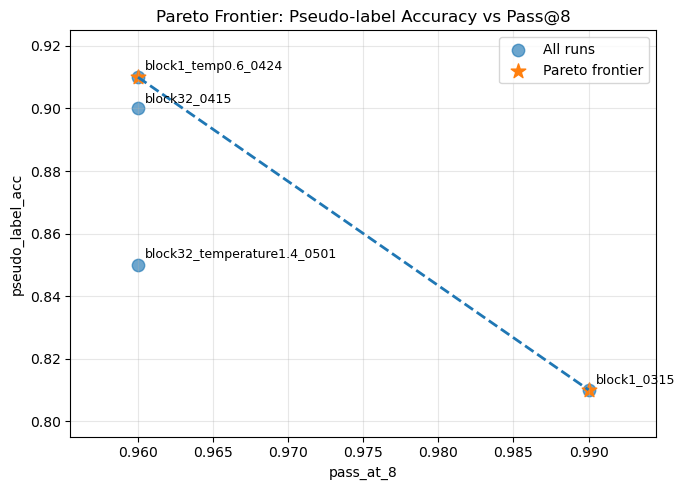


Pareto points:
                         label  pass_at_8  pseudo_label_acc  is_pareto
1                  block1_0315       0.99              0.81       True
2          block1_temp0.6_0424       0.96              0.91       True
0                 block32_0415       0.96              0.90      False
3  block32_temperature1.4_0501       0.96              0.85      False
Saved to plots/pareto_pass_at_8_vs_reward_acc.png


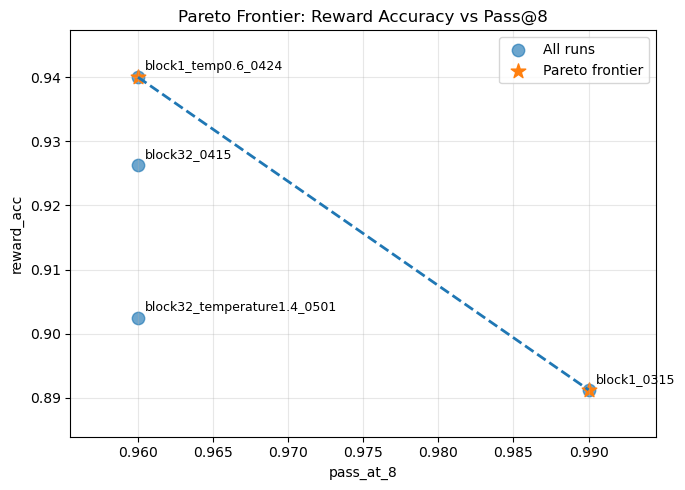


Pareto points:
                         label  pass_at_8  reward_acc  is_pareto
1                  block1_0315       0.99     0.89125       True
2          block1_temp0.6_0424       0.96     0.94000       True
0                 block32_0415       0.96     0.92625      False
3  block32_temperature1.4_0501       0.96     0.90250      False


In [ ]:
# 图1：pass@8 vs pseudo-label accuracy
pareto_pass_pseudo = plot_pareto_frontier_from_summary(
    summary_df=summary_df,
    x_metric="pass_at_8",
    y_metric="pseudo_label_acc",
    title="Pareto Frontier: Pseudo-label Accuracy vs Pass@8",
    save_dir="plots/",
    annotate=True,
)

# # 图2：pass@8 vs reward accuracy
# pareto_pass_reward = plot_pareto_frontier_from_summary(
#     summary_df=summary_df,
#     x_metric="pass_at_8",
#     y_metric="reward_acc",
#     title="Pareto Frontier: Reward Accuracy vs Pass@8",
#     save_dir="plots/",
#     annotate=True,
# )

画curve图

pseudo_label_acc: 280 raw points, 280 valid points in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
pseudo_label_acc: 144 raw points, 144 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log
Saved to plots/pseudo_label_acc.png


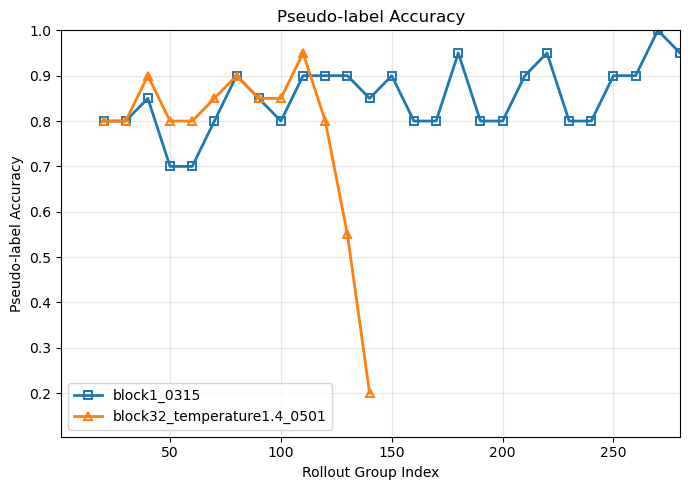

reward_acc: 280 raw points, 280 valid points in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
reward_acc: 144 raw points, 143 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log
Saved to plots/reward_acc.png


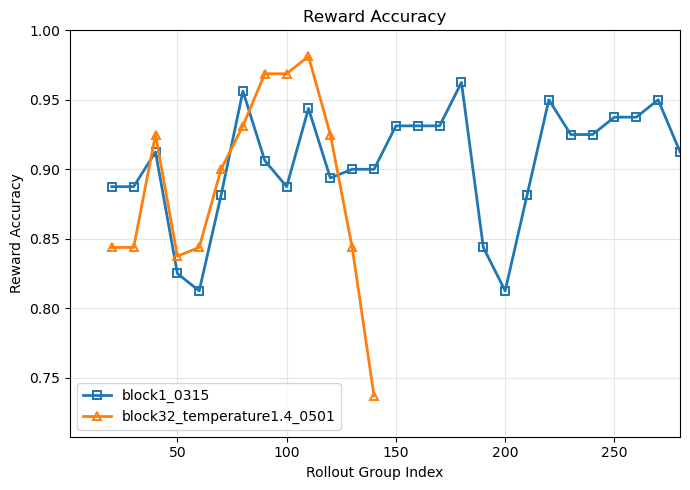

pass_at_8: 280 raw points, 280 valid points in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
pass_at_8: 144 raw points, 144 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log
Saved to plots/pass_at_8.png


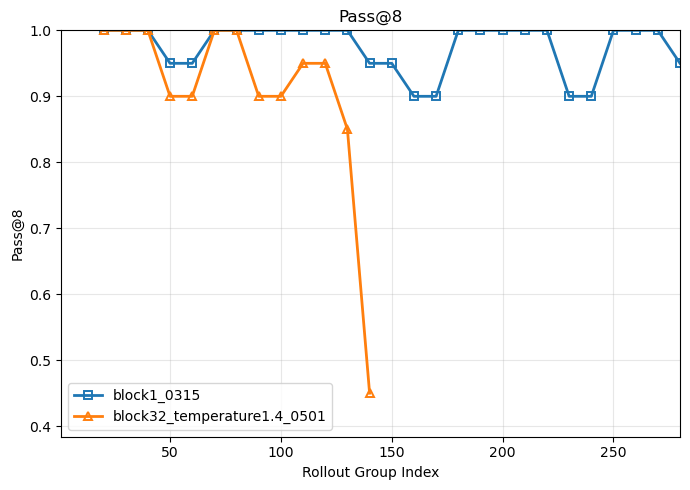

correct_answer_ratio: 280 raw points, 280 valid points in logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log
correct_answer_ratio: 144 raw points, 144 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log
Saved to plots/correct_answer_ratio.png


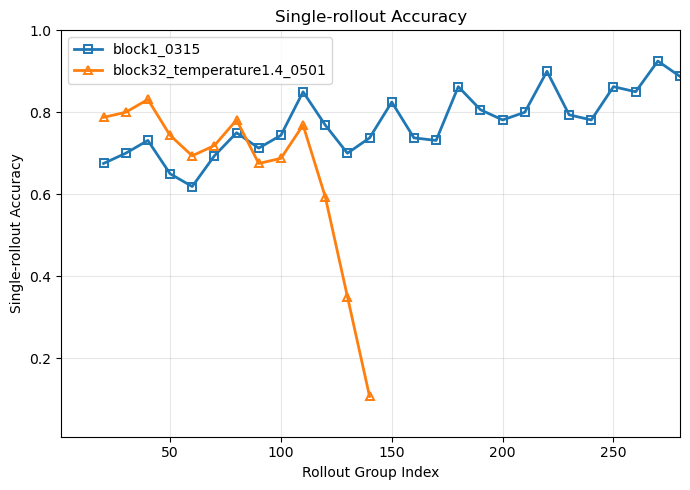

In [41]:
# # Notebook 里可以直接 display
# try:
#     display(summary_df)
# except NameError:
#     print(summary_df)



curve_log_files = [
    # low diversiy
    # "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log",
    # "logs/checkpoints_gsm8k_num_generation8_test_block1_temperature0.6_lr5e-6_0424.log",
    # high diversity
    "logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log",
    "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log"
    
]

plot_all_metrics_across_files(
    log_files=curve_log_files,
    save_dir="plots/",
    smooth_window=20,
    smooth_stride=10,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=TRUNCATE_TO_SHORTEST,
)

In [ ]:
def compare_two_logs(log_file1, log_file2, save_dir=None, window_size=40, step_size=3):
    """
    对比两个日志文件的voting accuracy和reward accuracy
    
    Args:
        log_file1: 第一个日志文件路径
        log_file2: 第二个日志文件路径
        save_dir: 保存图片的目录
        window_size: 平滑窗口大小
        step_size: 滑动步长
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
    
    def extract_data(log_file):
        data_list = []
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
        print(f"Extracted {len(data_list)} diversity entries from {log_file}")
        voting_acc_list = []
        reward_acc_list = []
        
        for data in data_list:
            if data['distinct_answer_num'] <= 1:
                continue
            voting_acc_list.append(data['best_is_correct'])
            
            if data['majority_answer'] and data['ground_truth']:
                answers = data['extracted_answers']
                majority = data['majority_answer']
                truth = data['ground_truth']
                tp = fp = tn = fn = 0
                for ans in answers:
                    est_reward = 1 if ans == majority else 0
                    true_reward = 1 if ans == truth else 0
                    if est_reward == 1 and true_reward == 1:
                        tp += 1
                    elif est_reward == 1 and true_reward == 0:
                        fp += 1
                    elif est_reward == 0 and true_reward == 0:
                        tn += 1
                    elif est_reward == 0 and true_reward == 1:
                        fn += 1
                total = tp + fp + tn + fn
                reward_acc_list.append((tp + tn) / total if total > 0 else 0)
            else:
                reward_acc_list.append(0)
        
        return voting_acc_list, reward_acc_list
    
    def sliding_window_avg(data, window, step):
        """滑动窗口平均，步长可调"""
        if len(data) < window:
            return data, np.arange(1, len(data) + 1)
        
        smoothed = []
        x_positions = []
        
        for start in range(0, len(data) - window + 1, step):
            end = start + window
            smoothed.append(np.mean(data[start:end]))
            x_positions.append((start + end) / 2 + 0.5)
        
        return smoothed, x_positions
    
    # 提取数据
    voting1, reward1 = extract_data(log_file1)
    voting2, reward2 = extract_data(log_file2)
    
    if not voting1 and not voting2:
        print("两个文件都没有有效数据")
        return
    
    # 创建两张图
    fig1, ax1 = plt.subplots(figsize=(8, 4))
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    
    name1 = Path(log_file1).stem
    name2 = Path(log_file2).stem
    
    # 四个颜色：橙色、蓝色、绿色、红色
    color_voting1 = '#E69F00'  # 橙色 - majority voting
    color_voting2 = '#d62728'  # 蓝色 - confidence-weighted voting
    color_reward1 = '#56B4E9'  # 绿色 - majority voting reward
    color_reward2 = '#009E73'  # 红色 - confidence-weighted voting reward
    
    # 图1: Voting Accuracy
    if voting1:
        smooth1, x1 = sliding_window_avg(voting1, window_size, step_size)
        ax1.plot(x1, smooth1, 'o-', color=color_voting1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax1.plot(np.arange(1, len(voting1)+1), voting1, '.', color=color_voting1, alpha=0.15, markersize=2)
    
    if voting2:
        smooth2, x2 = sliding_window_avg(voting2, window_size, step_size)
        ax1.plot(x2, smooth2, 'o-', color=color_voting2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax1.plot(np.arange(1, len(voting2)+1), voting2, '.', color=color_voting2, alpha=0.15, markersize=2)
    
    ax1.set_xlabel('Step', fontsize=16)
    ax1.set_ylabel('Pesudo Label Accuracy', fontsize=16)
    ax1.set_xlim(19, 71)
    ax1.set_ylim(0.55, 0.9)
    ax1.legend(loc='lower right', fontsize=16)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 图2: Reward Accuracy
    if reward1:
        smooth1, x1 = sliding_window_avg(reward1, window_size, step_size)
        ax2.plot(x1, smooth1, 'o-', color=color_reward1, linewidth=2, markersize=5,
                label=f'majority voting')
        ax2.plot(np.arange(1, len(reward1)+1), reward1, '.', color=color_reward1, alpha=0.15, markersize=2)
    
    if reward2:
        smooth2, x2 = sliding_window_avg(reward2, window_size, step_size)
        ax2.plot(x2, smooth2, 'o-', color=color_reward2, linewidth=2, markersize=5,
                label=f'confidence-weighted voting')
        ax2.plot(np.arange(1, len(reward2)+1), reward2, '.', color=color_reward2, alpha=0.15, markersize=2)
    
    ax2.set_xlabel('Step', fontsize=16)
    ax2.set_ylabel('Reward Accuracy', fontsize=16)
    ax2.set_xlim(19, 71)
    ax2.set_ylim(0.6, 0.9)
    ax2.legend(loc='lower right', fontsize=16)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    fig1.tight_layout()
    fig2.tight_layout()
    
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.png'), dpi=300, bbox_inches='tight')
        fig1.savefig(os.path.join(save_dir, 'voting_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
        fig2.savefig(os.path.join(save_dir, 'reward_acc_comparison.pdf'), dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close('all')
    
    # 打印统计
    print("\n" + "="*60)
    print("统计信息:")
    print("="*60)
    if voting1:
        print(f"{name1}: Voting={np.mean(voting1):.4f}±{np.std(voting1):.4f}, Reward={np.mean(reward1):.4f}±{np.std(reward1):.4f}")
    if voting2:
        print(f"{name2}: Voting={np.mean(voting2):.4f}±{np.std(voting2):.4f}, Reward={np.mean(reward2):.4f}±{np.std(reward2):.4f}")


# 使用
log1 = "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log"
log2 = "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.0_lr5e-6_0424_rank.log"

compare_two_logs(log1, log2, save_dir="figures", window_size=40, step_size=2)